In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [65]:
path = r"E:\NTI\Linear Regression\Mall_Customers.csv"

In [66]:
data = pd.read_csv(path)

In [67]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [68]:
data.shape

(200, 5)

In [69]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [70]:
data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [71]:
data.duplicated().sum()

0

In [72]:
data.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [73]:
X = data.iloc[: , 2:]
X

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18


In [74]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [75]:
from sklearn.mixture import GaussianMixture 

bic_scores = []
n_components_range = range(1, 11)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))

In [76]:
bic_scores

[1727.7216185293642,
 1656.9622134090284,
 1630.1713478692943,
 1596.999117373414,
 1627.5242076461357,
 1607.1469926614234,
 1630.2830271339558,
 1666.462958096448,
 1693.5420905771066,
 1728.6363692590355]

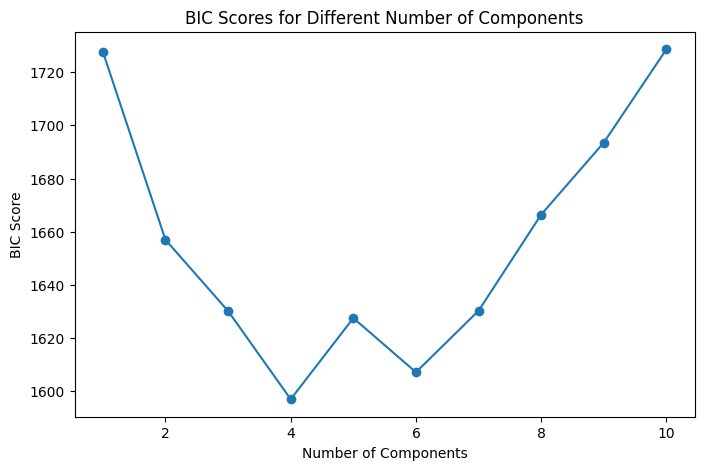

In [77]:
plt.figure(figsize=(8,5))
plt.plot(n_components_range, bic_scores, marker='o')
plt.title('BIC Scores for Different Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('BIC Score')
plt.show()

In [78]:
optimal_n= n_components_range[np.argmin(bic_scores)]
print(f"Optimal number of components: {optimal_n}")

Optimal number of components: 4


In [79]:
gmm = GaussianMixture(n_components=optimal_n, random_state=42)
gmm.fit(X_scaled)
labels = gmm.predict(X_scaled)
print(labels)

[0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 0 0 0 2 2 0 0 0 0 0 2 0 0 2 0 0 0 2 0 0 2 0 0 0 0 0
 0 2 0 0 2 0 0 0 0 0 2 0 0 2 0 0 0 2 0 0 2 2 0 2 0 2 2 0 0 2 0 2 0 0 0 0 0
 2 0 2 2 2 0 0 0 0 2 0 0 1 2 1 3 1 3 1 3 1 2 1 3 1 3 1 2 1 3 1 2 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


In [80]:
data['cluster'] = labels

In [81]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,0
1,2,Male,21,15,81,2
2,3,Female,20,16,6,0
3,4,Female,23,16,77,2
4,5,Female,31,17,40,0


In [82]:
from sklearn.metrics import silhouette_score
silhouette_avg = silhouette_score(X_scaled, labels)
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.3734466371028913


In [83]:
log_likelihood = gmm.score(X_scaled)
print(f"Log Likelihood: {log_likelihood}")

Log Likelihood: -3.4759118501951014


In [84]:
print(f"Means of clusters:{gmm.means_}")
print("-"*50)
print(f"weights of clusters:{gmm.weights_}")
print("-"*50)
print(f"Covariance of clusters:{gmm.covariances_}")

Means of clusters:[[ 0.79464628 -0.54962867 -0.35481071]
 [-0.44613802  0.99355244  1.23976564]
 [-1.03593668 -0.61886752  0.41229644]
 [ 0.28311654  1.07579503 -1.26037493]]
--------------------------------------------------
weights of clusters:[0.38424019 0.19307202 0.25690258 0.16578522]
--------------------------------------------------
Covariance of clusters:[[[ 0.78287365  0.13493598  0.08572747]
  [ 0.13493598  0.34624238  0.26068378]
  [ 0.08572747  0.26068378  0.37784159]]

 [[ 0.06892068 -0.01825704  0.01380084]
  [-0.01825704  0.38510762 -0.00740371]
  [ 0.01380084 -0.00740371  0.13218388]]

 [[ 0.12844383 -0.05986139  0.05123801]
  [-0.05986139  0.50374177 -0.46317164]
  [ 0.05123801 -0.46317164  0.58943425]]

 [[ 0.49965689 -0.04304606  0.04834626]
  [-0.04304606  0.39971377  0.04670847]
  [ 0.04834626  0.04670847  0.15511394]]]
